<a href="https://colab.research.google.com/github/RobertasBr/Blackjack-CA1/blob/master/legotraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

In [2]:
import zipfile
import os
import shutil

# Define the path to the zip file
zip_file_path = '/content/SmallLego.zip'

# Define the directory to extract the contents to
extract_dir = '/content/SmallLego'

# Check if the directory already exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# Create the extraction directory
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")

'/content/SmallLego.zip' unzipped to '/content/SmallLego' successfully.


# Model 1 - Last FC removed, FC5 added

In [45]:
basemodel = keras.applications.VGG16(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="vgg16",
)
x = basemodel.layers[-2].output
outputs = Dense(5, activation='softmax')(x)
model = Model(inputs=basemodel.input, outputs=outputs)
for layer in model.layers[:-1]:
    layer.trainable = False


In [33]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,281,029 (512.24 MB)

 Trainable params: 20,485 (80.02 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [46]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [47]:
# Train the model
EPOCHS = 10

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.8159 - loss: 0.5403 - val_accuracy: 0.9092 - val_loss: 0.2807
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.9483 - loss: 0.1743 - val_accuracy: 0.9219 - val_loss: 0.2511
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.9671 - loss: 0.1058 - val_accuracy: 0.9424 - val_loss: 0.2076
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.9869 - loss: 0.0614 - val_accuracy: 0.9453 - val_loss: 0.1996
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.9940 - loss: 0.0401 - val_accuracy: 0.9424 - val_loss: 0.1969
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - accuracy: 0.9973 - loss: 0.0287 - val_accuracy: 0.9434 - val_loss: 0.1851
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.9980 - loss: 0.0237 - val_accuracy: 0.9424 - val_loss: 0.1859
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.9997 - loss: 0.0170 - val_accu

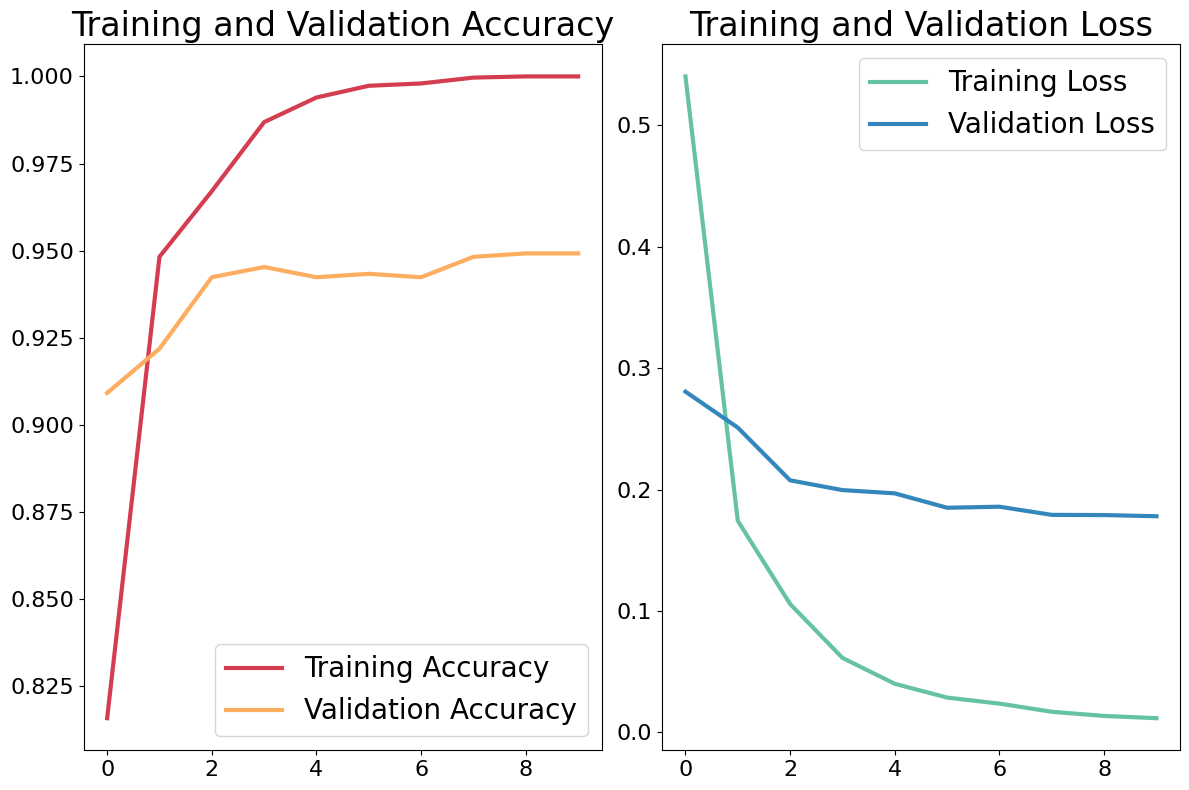

In [49]:
import matplotlib.pyplot as plt

# Get a color map for a consistent style
cmap = plt.get_cmap('Spectral')

# Plot training history
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))

# Left Plot: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color=cmap(0.1), linewidth=3)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color=cmap(0.3), linewidth=3)
plt.legend(loc='lower right', fontsize=20)
plt.title('Training and Validation Accuracy', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=16)

# Right Plot: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color=cmap(0.8), linewidth=3)
plt.plot(epochs_range, val_loss, label='Validation Loss', color=cmap(0.9), linewidth=3)
plt.legend(loc='upper right', fontsize=20)
plt.title('Training and Validation Loss', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

In [39]:
# Evaluate the model
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.9512 - loss: 0.1781
Validation Loss: 0.1781
Validation Accuracy: 0.9512


In [41]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.9340 - loss: 0.1849
Test Loss: 0.1849
Test Accuracy: 0.9340


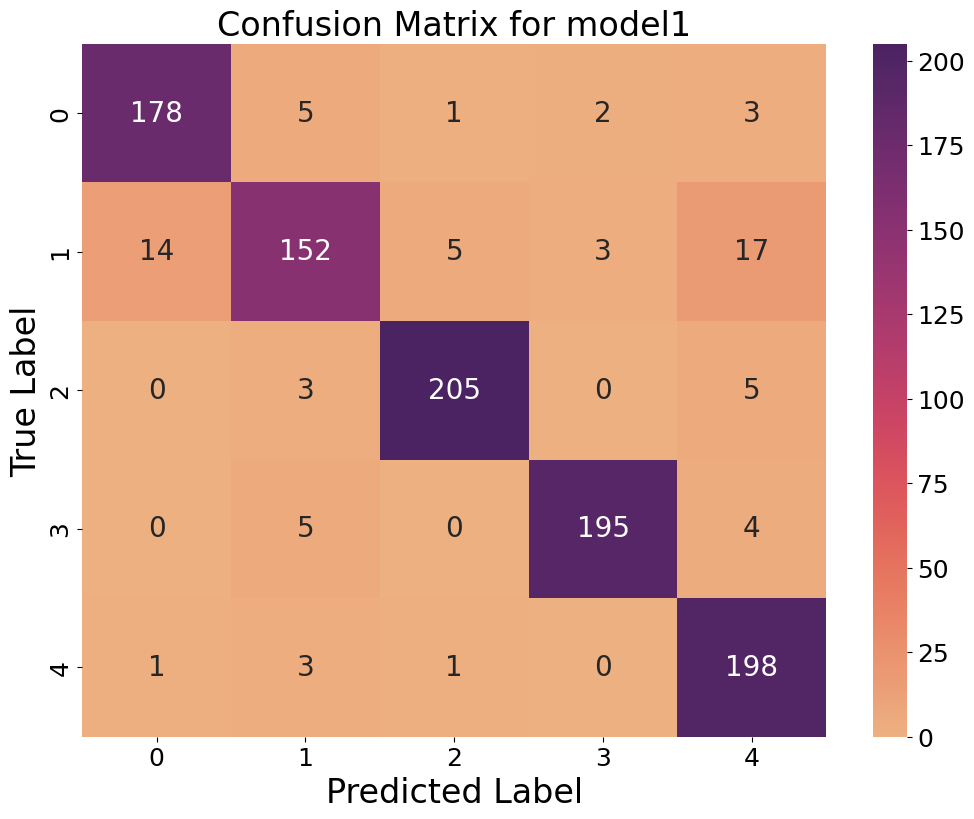

In [54]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Collect true labels and predictions from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize using a heatmap
plt.figure(figsize=(12, 9))
# Increased annot_kws for numbers and cbar_kws for the right axis scale
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='flare',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 20},
            cbar_kws={"shrink": 1})

# Set colorbar tick label size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.xlabel('Predicted Label', fontsize=24)
plt.ylabel('True Label', fontsize=24)
plt.title('Confusion Matrix for model1', fontsize=24)

# Making axis tick labels larger
plt.tick_params(axis='both', which='major', labelsize=18)

plt.show()

# Model Two - include_top = False

In [5]:
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense

model2_base = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling=None,
    name="vgg16_base",
)

# Freeze the layers of the base model
for layer in model2_base.layers:
    layer.trainable = False

# Add new classification head
x = Flatten()(model2_base.output)
output = Dense(units=5, activation='softmax')(x)

# Create the new model
model2 = keras.Model(inputs=model2_base.input, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │       125,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,133 (56.61 MB)

 Trainable params: 125,445 (490.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
import tensorflow as tf
import os
import shutil

data_dir = '/content/SmallLego'

macosx_dir = os.path.join(data_dir, '__MACOSX')
if os.path.exists(macosx_dir):
    print(f"Removing directory: {macosx_dir}")
    shutil.rmtree(macosx_dir)

DATA_SPLIT_SEED = 42
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_val_raw_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=DATA_SPLIT_SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=DATA_SPLIT_SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_val_raw_ds.class_names
print(f"Class names: {class_names}")

num_train_val_batches = tf.data.experimental.cardinality(train_val_raw_ds).numpy()

num_train_batches = int(num_train_val_batches * 0.75)

train_ds = train_val_raw_ds.take(num_train_batches)
val_ds = train_val_raw_ds.skip(num_train_batches)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Removing directory: /content/SmallLego/__MACOSX
Found 5000 files belonging to 5 classes.
Using 4000 files for training.
Found 5000 files belonging to 5 classes.
Using 1000 files for validation.
Class names: ['0', '1', '2', '3', '4']
Number of training batches: 93
Number of validation batches: 32
Number of test batches: 32


Now, let's compile the `model2`.

In [36]:
# Compile the model
model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Next, we will train `model2` using the prepared datasets.

In [9]:
# Train the model
EPOCHS = 10

history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 234ms/step - accuracy: 0.8881 - loss: 2.5156 - val_accuracy: 0.9619 - val_loss: 1.0897
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.9849 - loss: 0.2353 - val_accuracy: 0.9648 - val_loss: 1.1375
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.9892 - loss: 0.1727 - val_accuracy: 0.9512 - val_loss: 1.7629
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.9886 - loss: 0.1619 - val_accuracy: 0.9609 - val_loss: 1.5167
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.9946 - loss: 0.0618 - val_accuracy: 0.9668 - val_loss: 1.3719
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.9950 - loss: 0.0711 - val_accuracy: 0.9629 - val_loss: 1.5855
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.9976 - loss: 0.0318 - val_accuracy: 0.9600 - val_loss: 1.4763
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.9976 - loss: 0.0283 - val_accu

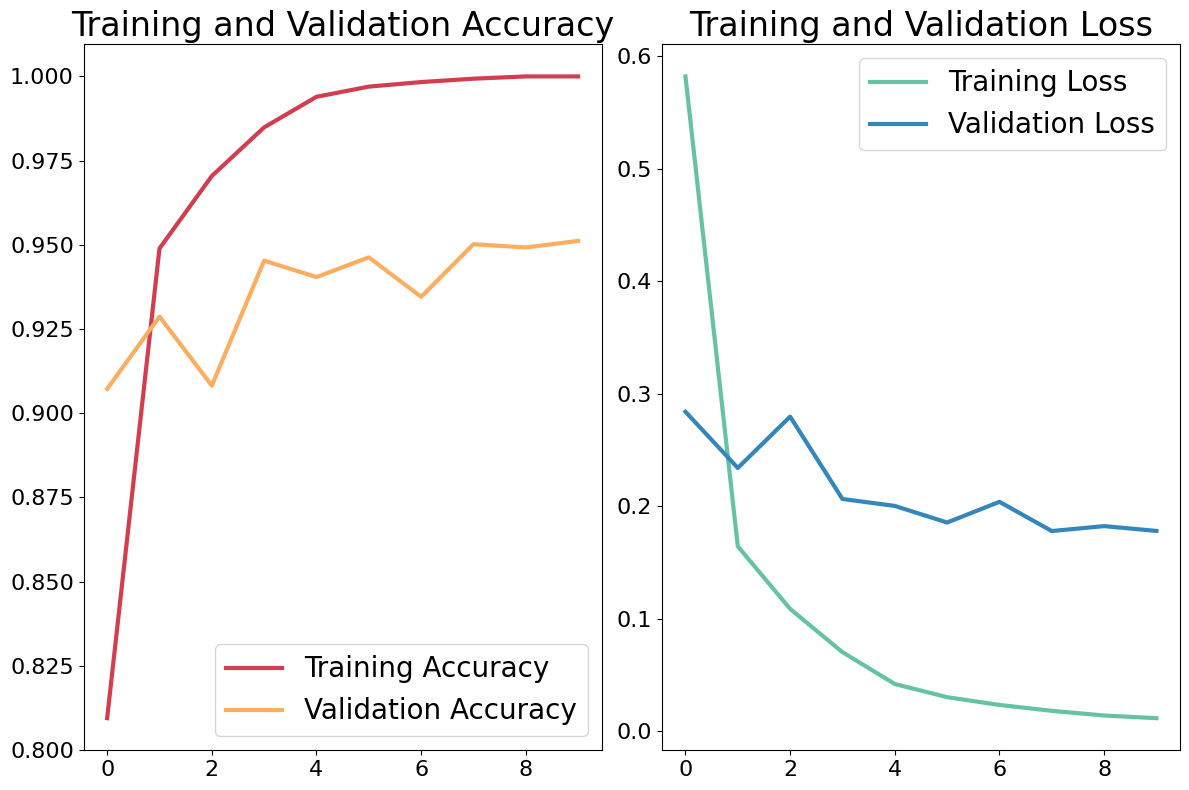

In [50]:
import matplotlib.pyplot as plt

# Get a color map for a consistent style
cmap = plt.get_cmap('Spectral')

# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))

# Left Plot: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color=cmap(0.1), linewidth=3)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color=cmap(0.3), linewidth=3)
plt.legend(loc='lower right', fontsize=20)
plt.title('Training and Validation Accuracy', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=16)

# Right Plot: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color=cmap(0.8), linewidth=3)
plt.plot(epochs_range, val_loss, label='Validation Loss', color=cmap(0.9), linewidth=3)
plt.legend(loc='upper right', fontsize=20)
plt.title('Training and Validation Loss', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

# Validation Dataset - Validation

In [11]:
# Evaluate the model
loss, accuracy = model2.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.9551 - loss: 2.3766
Validation Loss: 2.3766
Validation Accuracy: 0.9551


# Test Dataset - Validation

In [13]:
loss, accuracy = model2.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.9610 - loss: 1.6797
Test Loss: 1.6797
Test Accuracy: 0.9610


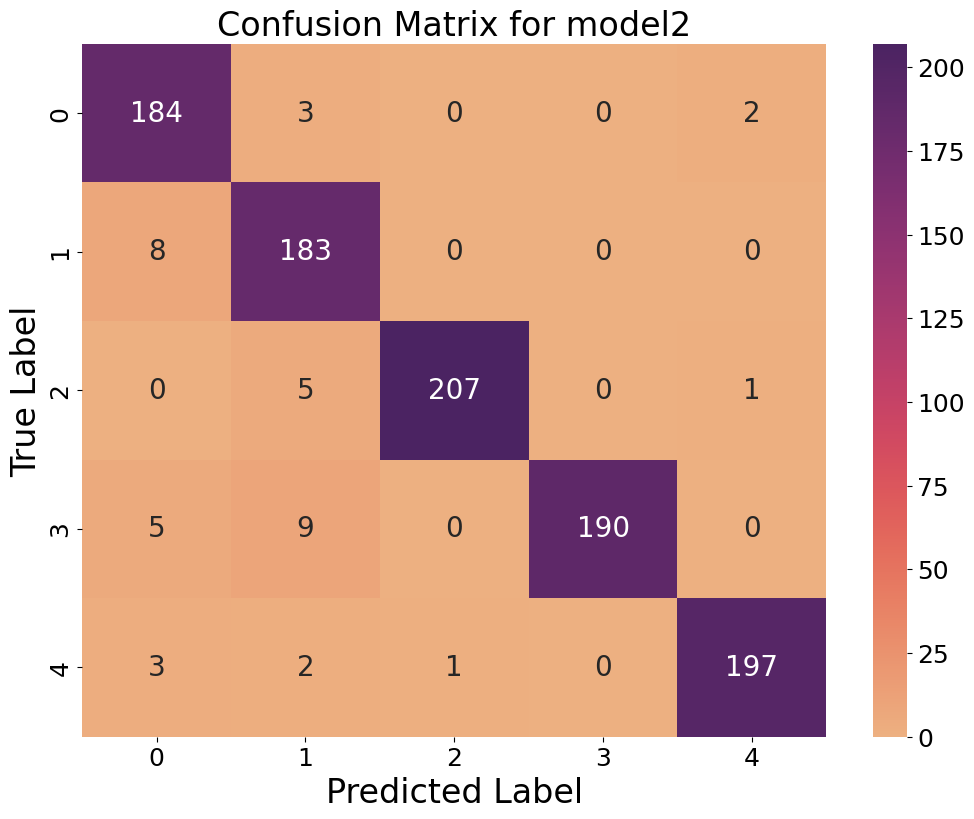

In [52]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Collect true labels and predictions from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize using a heatmap
plt.figure(figsize=(12, 9))
# Increased annot_kws for numbers and cbar_kws for the right axis scale
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='flare',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 20},
            cbar_kws={"shrink": 1})

# Set colorbar tick label size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.xlabel('Predicted Label', fontsize=24)
plt.ylabel('True Label', fontsize=24)
plt.title('Confusion Matrix for model2', fontsize=24)

# Making axis tick labels larger
plt.tick_params(axis='both', which='major', labelsize=18)

plt.show()